In [1]:
import importlib
import libpysal
import geopandas as gpd
import tools
importlib.reload(tools)
from spopt.region import Skater, WardSpatial
from sklearn.preprocessing import StandardScaler

In [2]:
gdfs_reg = ["south", "chicago", "ceara_zika"]

dataset_variables = {
    "south"      : ["HR90","UE90","DV90","FP89","BLK90"],
    "chicago"    : ['poverty', 'crowded', 'dependency', 'without_hs', 'unemployed','income_pc', 'harship_in', 'perc_crimes', 'perc_theft'],
    "ceara_zika" : ['mobility', 'environ','housing', 'sanitation', 'infra'],
}
scaler = StandardScaler()

In [3]:
for gdf_name in gdfs_reg:
    print(f"Computing {gdf_name}...")

    gdf = gpd.read_parquet(f"data/real/{gdf_name}.parquet")
    w = libpysal.graph.read_parquet(f"graphs/real/{gdf_name}/g_true.parquet").to_W()

    cluster_variables = dataset_variables[gdf_name]
    var_scaled = StandardScaler().fit_transform(gdf[cluster_variables].values) #standardization

    local_gdf = gpd.GeoDataFrame(geometry=gdf.geometry)
    temp_cols = [f"v_{i}" for i in range(len(cluster_variables))]
    local_gdf[temp_cols] = var_scaled

    # SCHC
    try:
        model_ward = WardSpatial(
            gdf=local_gdf,
            w=w,
            attrs_name=temp_cols,
            n_clusters=5
        )
        model_ward.solve()
        gdf["true_ward"] = model_ward.labels_
    except Exception as e:
        print(f"  WardSpatial failed for {gdf_name}: {e}")
        gdf["true_ward"] = -1

    # SKATER
    try:
        model_skater = Skater(
            gdf=local_gdf,
            w=w,
            attrs_name=temp_cols,
            n_clusters=5,
            floor=1,
            islands="error"   # true graph should be fully connected — error is appropriate here
        )
        model_skater.solve()
        gdf["true_skater"] = model_skater.labels_
    except Exception as e:
        print(f"  Skater failed for {gdf_name}: {e}")
        gdf["true_skater"] = -1

    # Save
    gdf.to_parquet(f"data/real/{gdf_name}.parquet")
    print(f"  Saved: true_ward + true_skater → data/real/{gdf_name}.parquet\n")

Computing south...
  Saved: true_ward + true_skater → data/real/south.parquet

Computing chicago...
  Saved: true_ward + true_skater → data/real/chicago.parquet

Computing ceara_zika...
  Saved: true_ward + true_skater → data/real/ceara_zika.parquet



<Axes: >

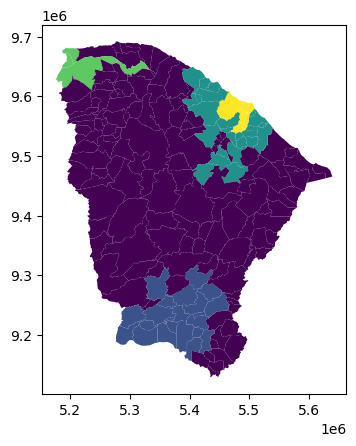

In [10]:
gdf.plot(column = "true_ward")

In [11]:
south = gpd.read_parquet("data/real/south.parquet")

<Axes: >

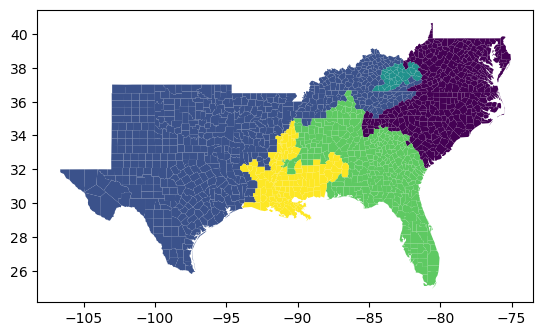

In [13]:
south.plot(column = "true_skater")

In [15]:
g_south = libpysal.graph.read_parquet("graphs/real/south/g_true.parquet")

In [16]:
g_south

<Graph of 1412 nodes and 7700 nonzero edges (1 component, 0 isolates) indexed by
 [0, 1, 2, 3, 4, ...]>